In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

In [2]:
alpha = 0.05
n = 3
m = 2

x_n = np.array([-1.11, -6.10, 2.42])
y_m = np.array([-2.29, -2.91])

var_x = 2
var_y = 1

In [3]:
delta_obs = x_n.mean() - y_m.mean()

SE = np.sqrt(var_x / n + var_y / m)

Z_obs = delta_obs / SE

N_std = stats.norm(loc=0, scale=1)

print(f"Разность средних (delta): {delta_obs}")
print(f"Стандартная ошибка (SE): {SE}")
print(f"Наблюдаемое значение Z_obs: {Z_obs}")

Разность средних (delta): 1.0033333333333334
Стандартная ошибка (SE): 1.0801234497346432
Наблюдаемое значение Z_obs: 0.9289061667717935


In [4]:
z_alpha = N_std.ppf(1 - alpha)
print(f"Критическое значение z_{{1-alpha}}: {z_alpha}")

Критическое значение z_{1-alpha}: 1.6448536269514722


In [5]:
p_value = N_std.sf(Z_obs)
print(f"p-value: {p_value}")

p-value: 0.17646885841229104


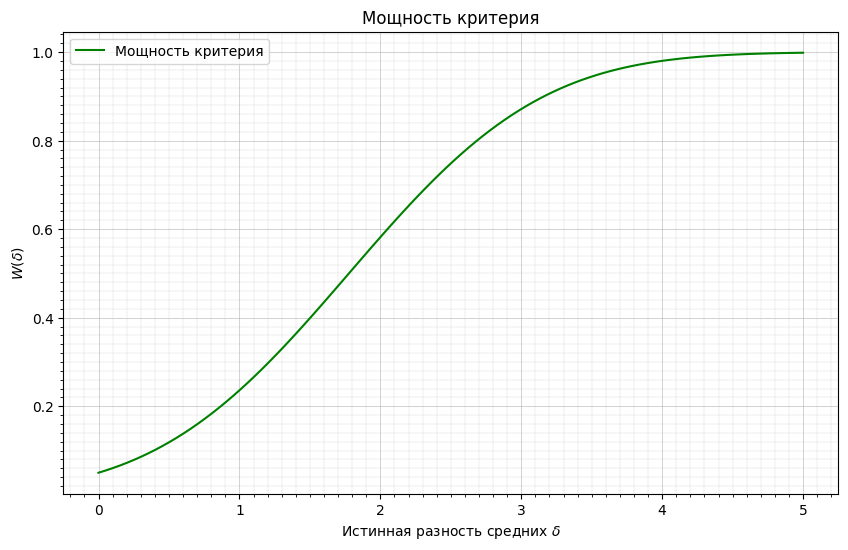

In [6]:
fig, axs = plt.subplots(1, 1, figsize=(10, 6))

axs.set_title("Мощность критерия")
axs.set_xlabel(r"Истинная разность средних $\delta$")
axs.set_ylabel(r"$W(\delta)$")

d = np.linspace(0, 5, 100)
power = N_std.sf(z_alpha - d / SE)

axs.plot(d, power, label="Мощность критерия", color="green")

axs.xaxis.set_minor_locator(AutoMinorLocator(10))
axs.yaxis.set_minor_locator(AutoMinorLocator(10))

plt.grid(which='minor', linestyle='--', linewidth=0.2)
plt.grid(which='major', linewidth=0.4)
plt.legend()

plt.show()